In [6]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
folder_path = './client'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_client = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [8]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_server = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [9]:
df_client_grouped = df_client.groupby(["Transport Protocol", "Scenario", "Distance (m)"]).mean().reset_index()

df_server_grouped = df_server.groupby(["Transport Protocol", "Scenario", "Distance (m)"]).mean().reset_index()

df_combined = pd.merge(df_client_grouped, df_server_grouped, on=["Transport Protocol", "Scenario", "Distance (m)"], how="inner")


In [10]:
# df_combined = pd.merge(
#     df_client,
#     df_server,
#     on=["Transport Protocol", "Scenario", "Distance (m)"],
#     how="inner"  # Only rows that exist in both will be kept
# )

In [11]:
df_combined

,Transport Protocol,Scenario,Distance (m),Average RTT (ms),Jitter (ms),Transfer Speed (Mbps),Package Loss (%),Package Size (Bytes),Number of Packages
0,QUIC,Inner City,1,190.968252,14.504792,197.150573,0.000000e+00,4466.285714,3603.571429
1,QUIC,Inner City,10,162.233439,13.719687,141.449595,-5.555556e-01,4480.000000,3700.000000
2,QUIC,Inner City,30,140.434961,11.312242,159.273423,2.592593e-07,4480.000000,3700.000000
3,TCP,Inner City,1,179.701561,13.840683,170.861594,0.000000e+00,4466.285714,3603.571429
4,TCP,Inner City,10,185.365515,10.381127,85.854591,0.000000e+00,4480.000000,3700.000000
5,TCP,Inner City,30,99.383921,9.392130,97.493420,0.000000e+00,4480.000000,3700.000000
6,UDP,Inner City,1,207.437691,15.578431,223.073934,1.952714e+01,4466.285714,3603.571429
7,UDP,Inner City,10,101.581199,9.704464,145.620728,2.768852e+01,4480.000000,3700.000000
8,UDP,Inner City,30,87.037158,9.377988,151.888427,2.324037e+01,4480.000000,3700.000000


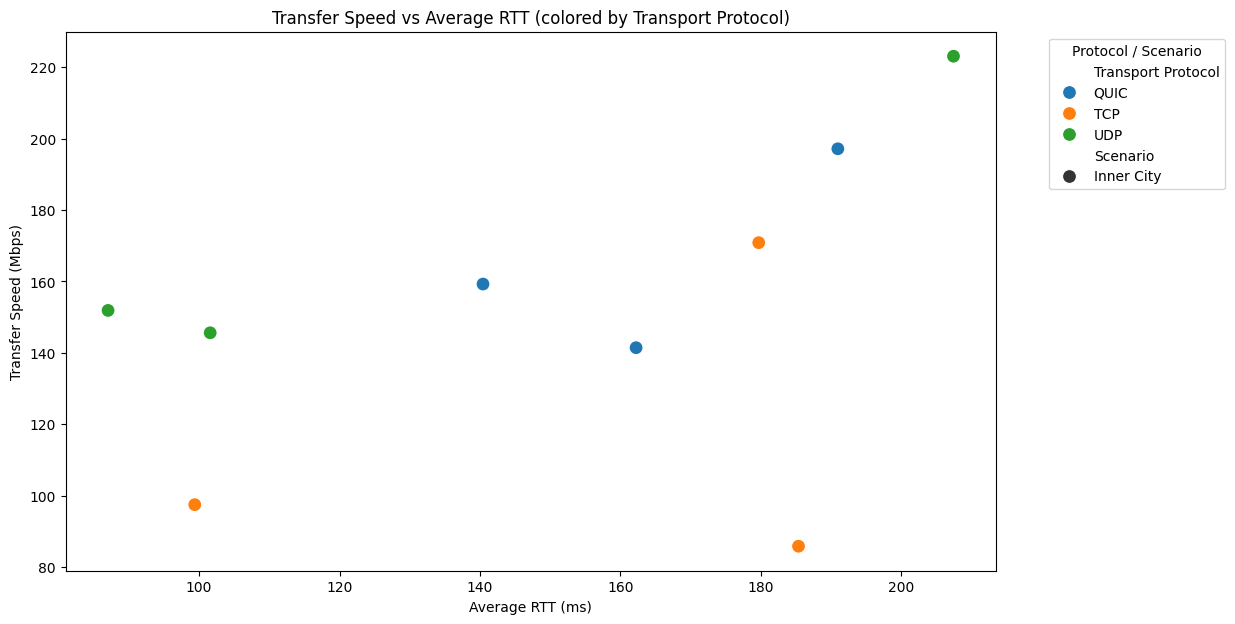

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Average RTT (ms)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    data=df_combined,
    s=100
)
plt.title('Transfer Speed vs Average RTT (colored by Transport Protocol)')
plt.xlabel('Average RTT (ms)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

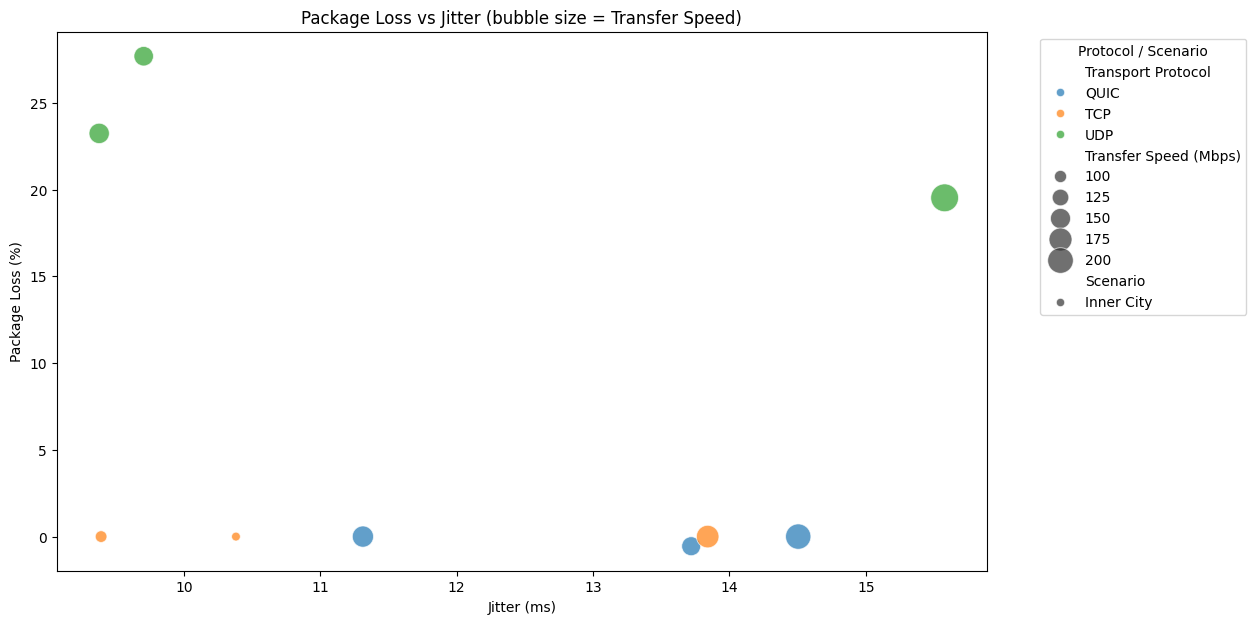

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Jitter (ms)', 
    y='Package Loss (%)', 
    size='Transfer Speed (Mbps)', 
    hue='Transport Protocol',
    style='Scenario',
    data=df_combined,
    sizes=(40, 400),
    alpha=0.7
)
plt.title('Package Loss vs Jitter (bubble size = Transfer Speed)')
plt.xlabel('Jitter (ms)')
plt.ylabel('Package Loss (%)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

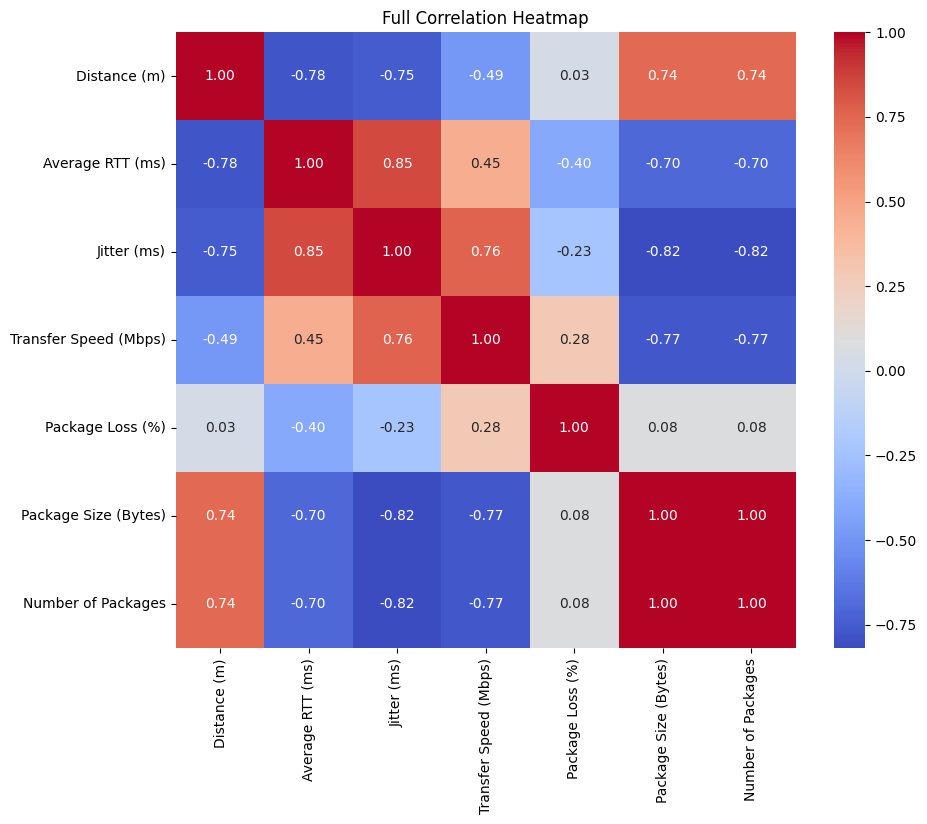

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_combined.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Full Correlation Heatmap')
plt.show()

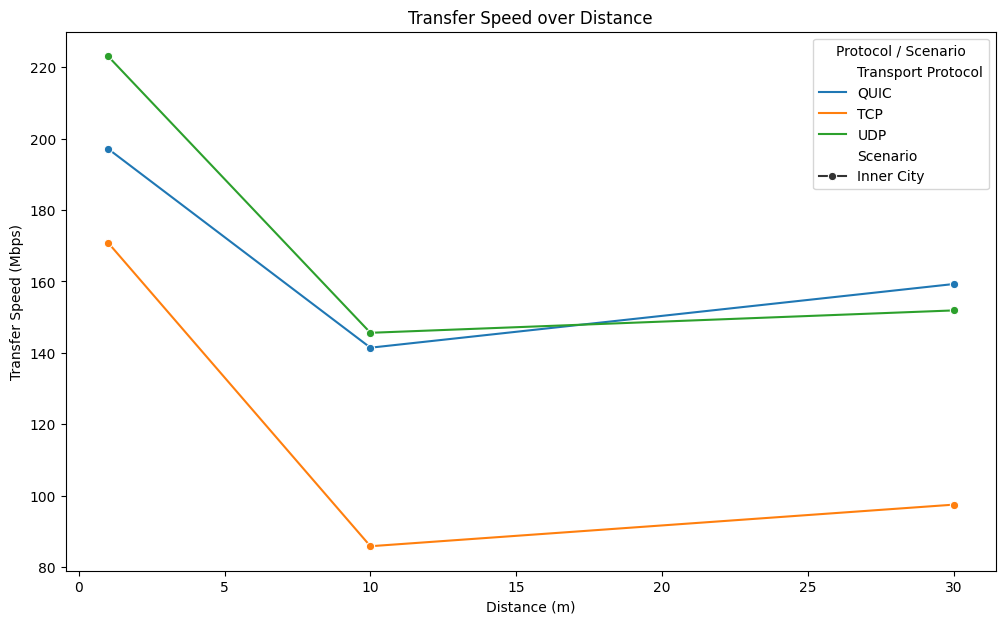

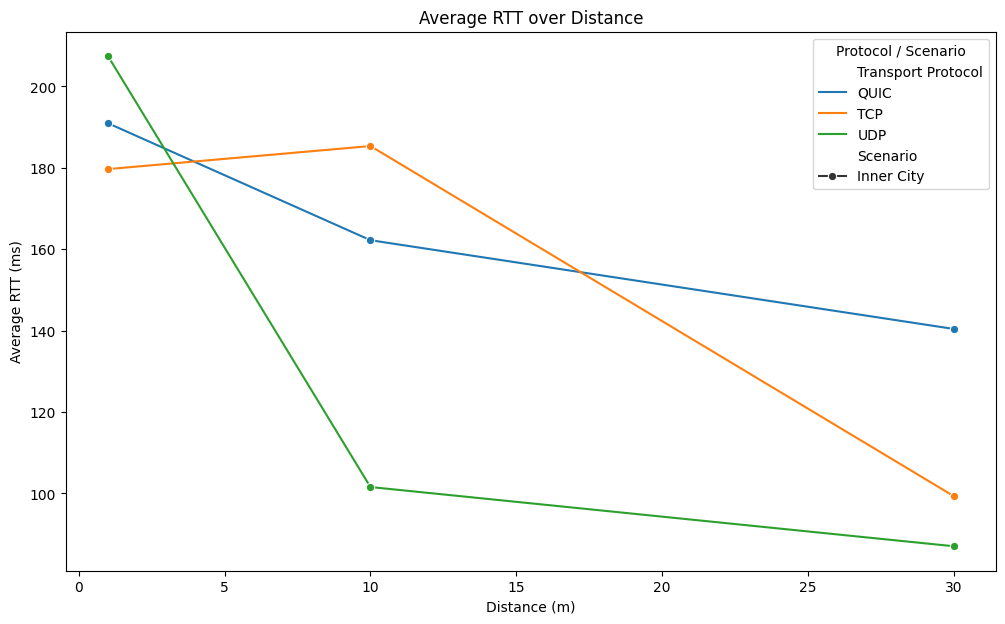

In [15]:
plt.figure(figsize=(12, 7))

# Plot Transfer Speed
sns.lineplot(
    x='Distance (m)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df_combined,
    legend='full'
)
plt.title('Transfer Speed over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario')
plt.show()

# Plot RTT separately
plt.figure(figsize=(12, 7))
sns.lineplot(
    x='Distance (m)', 
    y='Average RTT (ms)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df_combined,
    legend='full'
)
plt.title('Average RTT over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Average RTT (ms)')
plt.legend(title='Protocol / Scenario')
plt.show()